# Unsupervised Learning

## Load Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris, load_wine, load_digits, make_moons
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# Clustering

## K-Means

In [ ]:
iris = load_iris()
print(iris.target_names)
print(iris.feature_names)

iris_train = iris.data[:, [0, 2]]

['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


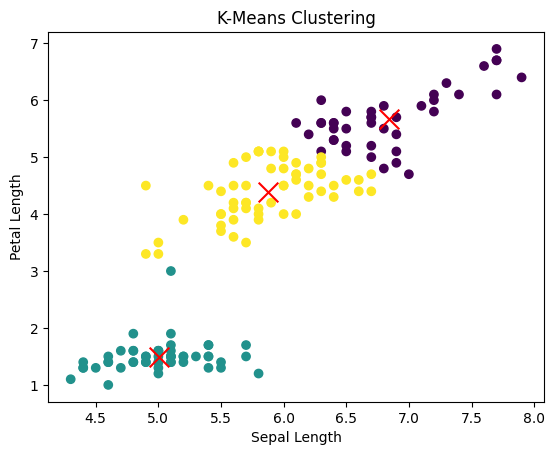

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(iris_train)

plt.scatter(iris_train[:, 0], iris_train[:, 1], c=kmeans.labels_, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=200, c='red', marker='x')
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.title('K-Means Clustering')
plt.show()

### elbow method

In [4]:
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(iris_train)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

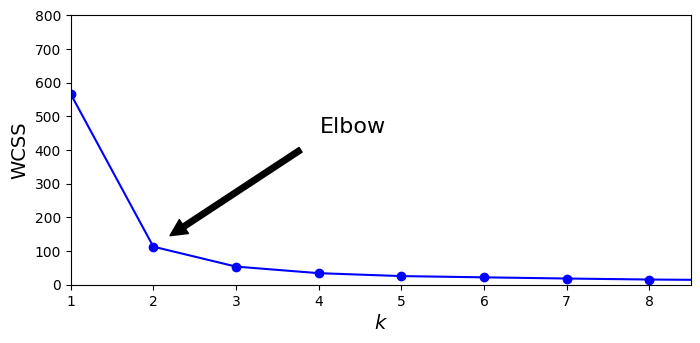

In [24]:
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("WCSS", fontsize=14)
plt.annotate('Elbow',
             xy=(2, inertias[1]),
             xytext=(0.4, 0.6),
             textcoords='figure fraction',
             fontsize=16,
             arrowprops=dict(facecolor='black', shrink=0.1)
            )
plt.axis([1, 8.5, 0, 800])
plt.show()

### sihlouette method

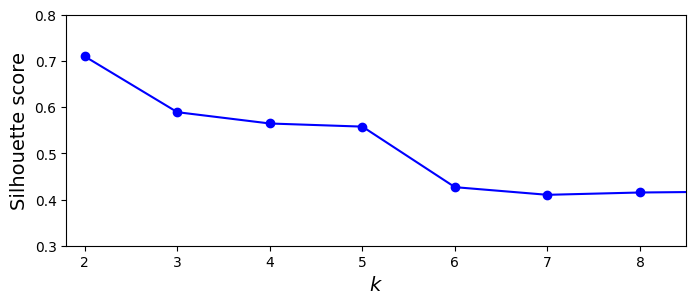

In [29]:
silhouette_scores = [silhouette_score(iris_train, model.labels_)
                     for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.axis([1.8, 8.5, 0.3, 0.8])
plt.show()

## K-Means Applications

### Color Segmentation

In [74]:
from matplotlib.image import imread
image = imread("nature.jpeg")
image.shape

(1707, 2560, 3)

In [77]:
X = image.reshape(-1, 3)

segmented_imgs = []
n_colors = (10, 8, 6, 4, 2)
for n_clusters in n_colors:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(X)
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]
    segmented_img = segmented_img.astype(np.uint8)
    segmented_imgs.append(segmented_img.reshape(image.shape))

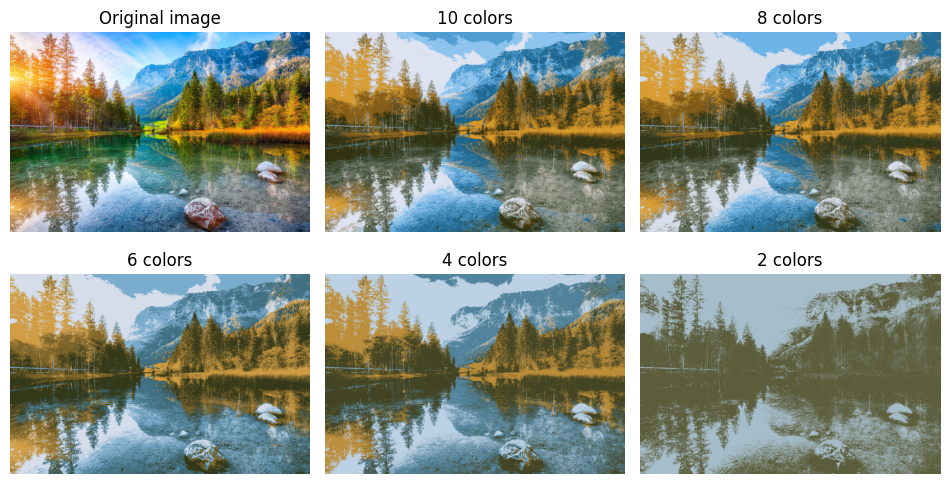

In [84]:
plt.figure(figsize=(12,6))
plt.subplots_adjust(wspace=0.05, hspace=0.1)

plt.subplot(231)
plt.imshow(image)
plt.title("Original image")
plt.axis('off')

for idx, n_clusters in enumerate(n_colors):
    plt.subplot(232 + idx)
    plt.imshow(segmented_imgs[idx])
    plt.title("{} colors".format(n_clusters))
    plt.axis('off')

plt.show()

### Preprocessing

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_digits, y_digits = load_digits(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, random_state=42)
log_reg = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
log_reg.fit(X_train, y_train)

g:\Programming exercise\python exercise\machine learning ex\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=5000, multi_class='ovr', random_state=42)

In [101]:
log_reg_score = log_reg.score(X_test, y_test)
log_reg_score

0.9688888888888889

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("kmeans", KMeans(n_clusters=50, random_state=42)),
    ("log_reg", LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)),
]
)
pipeline.fit(X_train, y_train)

g:\Programming exercise\python exercise\machine learning ex\ml_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('kmeans', KMeans(n_clusters=99, random_state=42)),
                ('log_reg',
                 LogisticRegression(max_iter=5000, multi_class='ovr',
                                    random_state=42))])

In [105]:
pipeline_score = pipeline.score(X_test, y_test)
pipeline_score

0.9822222222222222

## DBSCAN(Density-Based Spatial Clusterning of Application with Noise)

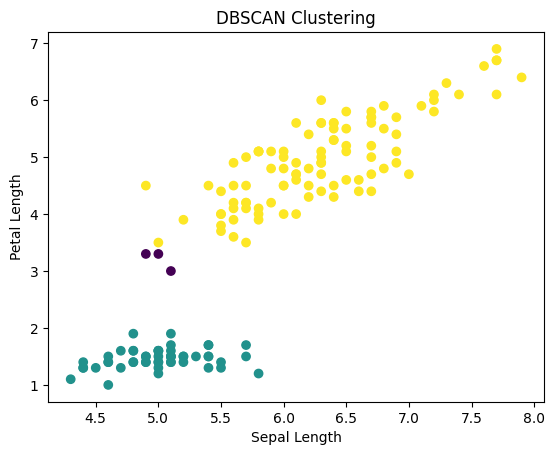

In [6]:
dbscan1 = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan1.fit_predict(iris_train)

plt.scatter(iris_train[:, 0], iris_train[:, 1], c=labels, cmap='viridis')
plt.xlabel('Sepal Length')
plt.ylabel('Petal Length')
plt.title('DBSCAN Clustering')
plt.show()

In [42]:
X, y = make_moons(n_samples=1000, noise=0.05)
dbscan2 = DBSCAN(eps=0.05, min_samples=5)
dbscan2.fit(X)

DBSCAN(eps=0.05)

In [54]:
dbscan3 = DBSCAN(eps=0.2, min_samples=5)
dbscan3.fit(X)

DBSCAN(eps=0.2)

In [57]:
dbscan4 = DBSCAN(eps=0.4, min_samples=5)
dbscan4.fit(X)

DBSCAN(eps=0.4)

In [36]:
def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]
    
    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20, c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1], c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=14)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=14, rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title("eps={:.2f}, min_samples={}".format(dbscan.eps, dbscan.min_samples), fontsize=14)

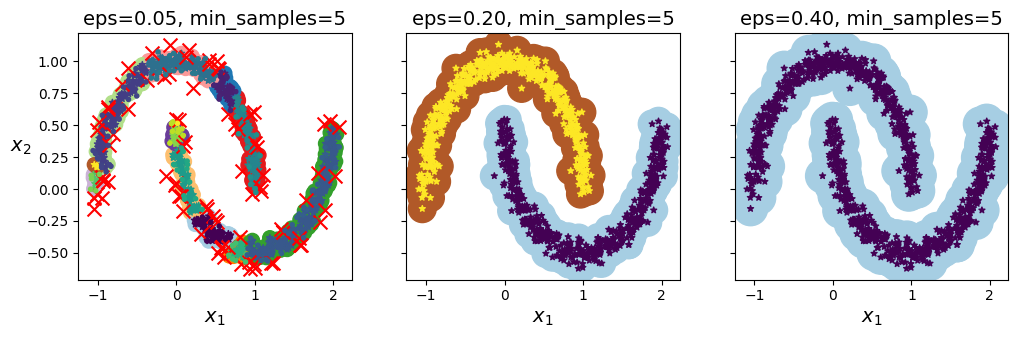

In [66]:
plt.figure(figsize=(12, 3.2))

plt.subplot(131)
plot_dbscan(dbscan2, X, size=100)

plt.subplot(132)
plot_dbscan(dbscan3, X, size=400, show_ylabels=False)

plt.subplot(133)
plot_dbscan(dbscan4, X, size=600, show_ylabels=False)

plt.show()

# Anomaly Detection

## Statistical Methods

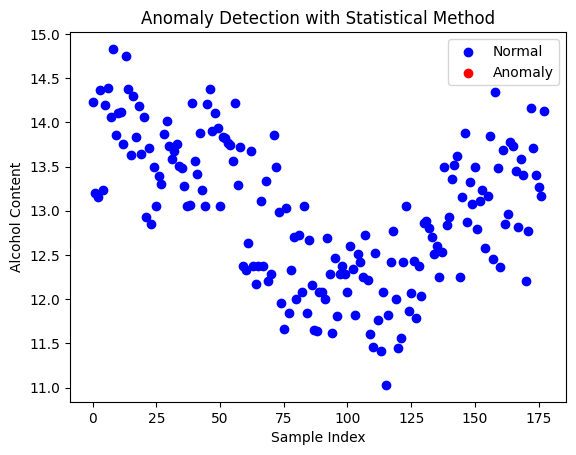

In [10]:
wine = load_wine()
X = wine.data[:, 0]

mu = np.mean(X)
sigma = np.std(X)
z_scores = (X - mu) / sigma

anomalies = np.abs(z_scores) > 3

plt.scatter(range(len(X)), X, c='blue', label='Normal')
plt.scatter(np.where(anomalies)[0], X[anomalies], c='red', label='Anomaly')
plt.xlabel('Sample Index')
plt.ylabel('Alcohol Content')
plt.title('Anomaly Detection with Statistical Method')
plt.legend()
plt.show()

# Dimensionality Reduction

## PCA

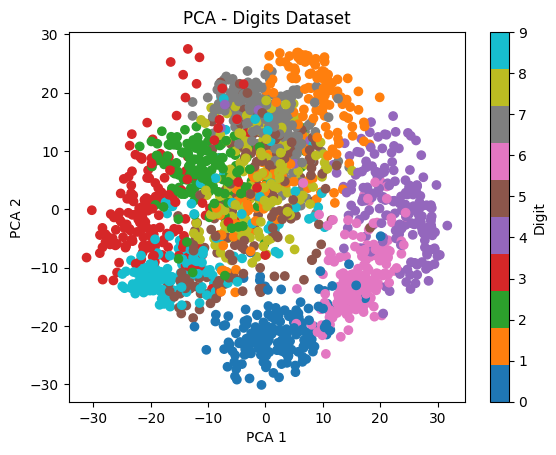

In [11]:
digits = load_digits()
X = digits.data
y = digits.target

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PCA - Digits Dataset')
plt.colorbar(label='Digit')
plt.show()

## t-SNE

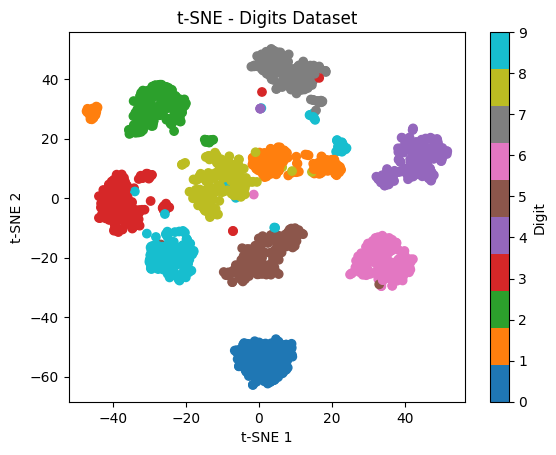

In [12]:
digits = load_digits()
X = digits.data
y = digits.target

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab10')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE - Digits Dataset')
plt.colorbar(label='Digit')
plt.show()